In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

development_df = pd.read_csv("../../data/processed/development_unscaled.csv")

X = development_df.drop(columns=["id", "diagnosis"]).values
y = development_df["diagnosis"].values

print(X.shape)
print(y.shape)

(455, 30)
(455,)


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [4]:
def compute_loss(y, y_hat):
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    return -np.mean(
        y * np.log(y_hat) +
        (1 - y) * np.log(1 - y_hat)
    )

In [5]:
def initialize_parameters(n_features):
    theta = np.zeros(n_features)
    bias = 0.0

    return theta, bias

In [6]:
def compute_gradients(X, y, y_hat):
    m = X.shape[0]

    d_theta = (1 / m) * X.T @ (y_hat - y)
    d_bias = (1 / m) * np.sum(y_hat - y)

    return d_theta, d_bias

In [7]:
theta, bias = initialize_parameters(X.shape[1])

z = X @ theta + bias
y_hat = sigmoid(z)

d_theta, d_bias = compute_gradients(
    X,
    y,
    y_hat
)

print("Theta shape:", theta.shape)
print("Prediction shape:", y_hat.shape)
print("Gradient shape:", d_theta.shape)
print("Bias gradient:", d_bias)
print("Initial loss:", compute_loss(y, y_hat))

Theta shape: (30,)
Prediction shape: (455,)
Gradient shape: (30,)
Bias gradient: 0.12637362637362637
Initial loss: 0.6931471805599453


In [8]:
def train_logistic_regression(
    X,
    y,
    learning_rate=0.01,
    iterations=1000
):

    n_samples, n_features = X.shape

    theta = np.zeros(n_features)
    bias = 0.0

    loss_history = []

    for i in range(iterations):

        # Linear combination
        z = X @ theta + bias

        # Predicted probabilities
        y_hat = sigmoid(z)

        # Compute loss
        loss = compute_loss(y, y_hat)
        loss_history.append(loss)

        # Compute gradients
        d_theta, d_bias = compute_gradients(
            X,
            y,
            y_hat
        )

        # Update parameters
        theta -= learning_rate * d_theta
        bias -= learning_rate * d_bias

        # Print progress every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {loss:.6f}")

    return theta, bias, loss_history

In [9]:
theta, bias, loss_history = train_logistic_regression(
    X_scaled,
    y,
    learning_rate=0.01,
    iterations=1000
)

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.250198
Iteration 200: Loss = 0.187135
Iteration 300: Loss = 0.158738
Iteration 400: Loss = 0.142030
Iteration 500: Loss = 0.130812
Iteration 600: Loss = 0.122651
Iteration 700: Loss = 0.116385
Iteration 800: Loss = 0.111385
Iteration 900: Loss = 0.107279


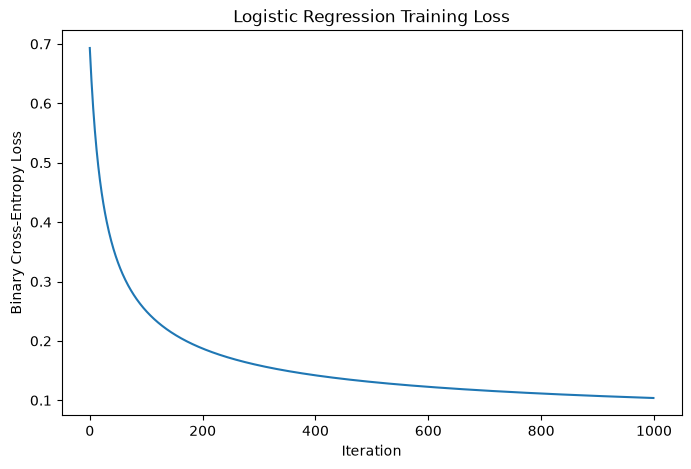

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Logistic Regression Training Loss")
plt.show()

In [11]:
def predict_probabilities(X, theta, bias):
    z = X @ theta + bias
    return sigmoid(z)


def predict_classes(X, theta, bias, threshold=0.5):
    probabilities = predict_probabilities(X, theta, bias)
    return (probabilities >= threshold).astype(int)

In [12]:
y_pred = predict_classes(X_scaled, theta, bias)

print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y[:10])

First 10 predictions: [1 0 0 1 1 1 0 1 0 1]
First 10 actual values: [1 0 0 1 1 1 0 1 1 1]


In [13]:
accuracy = np.mean(y_pred == y)

print(f"Development accuracy: {accuracy:.4f}")

Development accuracy: 0.9780


In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [15]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for fold, (train_index, validation_index) in enumerate(
    skf.split(X, y),
    start=1
):
    # Separate this fold's training and validation data
    X_train_fold = X[train_index]
    X_validation_fold = X[validation_index]

    y_train_fold = y[train_index]
    y_validation_fold = y[validation_index]

    # Fit the scaler only on this fold's training data
    fold_scaler = StandardScaler()

    X_train_scaled = fold_scaler.fit_transform(X_train_fold)
    X_validation_scaled = fold_scaler.transform(X_validation_fold)

    # Train the manual logistic regression model
    fold_theta, fold_bias, fold_loss_history = train_logistic_regression(
        X_train_scaled,
        y_train_fold,
        learning_rate=0.01,
        iterations=1000
    )

    # Predict validation probabilities and classes
    validation_probabilities = predict_probabilities(
        X_validation_scaled,
        fold_theta,
        fold_bias
    )

    validation_predictions = (
        validation_probabilities >= 0.5
    ).astype(int)

    # Calculate metrics
    fold_accuracy = accuracy_score(
        y_validation_fold,
        validation_predictions
    )

    fold_precision = precision_score(
        y_validation_fold,
        validation_predictions
    )

    fold_recall = recall_score(
        y_validation_fold,
        validation_predictions
    )

    fold_f1 = f1_score(
        y_validation_fold,
        validation_predictions
    )

    fold_roc_auc = roc_auc_score(
        y_validation_fold,
        validation_probabilities
    )

    cv_results.append({
        "fold": fold,
        "accuracy": fold_accuracy,
        "precision": fold_precision,
        "recall": fold_recall,
        "f1": fold_f1,
        "roc_auc": fold_roc_auc
    })

    print(
        f"Fold {fold}: "
        f"Accuracy = {fold_accuracy:.4f}, "
        f"Precision = {fold_precision:.4f}, "
        f"Recall = {fold_recall:.4f}, "
        f"F1 = {fold_f1:.4f}, "
        f"ROC-AUC = {fold_roc_auc:.4f}"
    )

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.249603
Iteration 200: Loss = 0.185788
Iteration 300: Loss = 0.156869
Iteration 400: Loss = 0.139774
Iteration 500: Loss = 0.128243
Iteration 600: Loss = 0.119818
Iteration 700: Loss = 0.113324
Iteration 800: Loss = 0.108125
Iteration 900: Loss = 0.103842
Fold 1: Accuracy = 0.9670, Precision = 1.0000, Recall = 0.9118, F1 = 0.9538, ROC-AUC = 0.9959
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.262108
Iteration 200: Loss = 0.198193
Iteration 300: Loss = 0.168991
Iteration 400: Loss = 0.151644
Iteration 500: Loss = 0.139911
Iteration 600: Loss = 0.131328
Iteration 700: Loss = 0.124711
Iteration 800: Loss = 0.119414
Iteration 900: Loss = 0.115054
Fold 2: Accuracy = 0.9780, Precision = 0.9444, Recall = 1.0000, F1 = 0.9714, ROC-AUC = 0.9990
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.245191
Iteration 200: Loss = 0.183380
Iteration 300: Loss = 0.155809
Iteration 400: Loss = 0.139718
Iteration 500: Loss = 0.129029
Iteration 60

In [16]:
cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

print("\nMean cross-validation results:")

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    mean_value = cv_results_df[metric].mean()
    std_value = cv_results_df[metric].std()

    print(
        f"{metric.capitalize()}: "
        f"{mean_value:.4f} ± {std_value:.4f}"
    )

,fold,accuracy,precision,recall,f1,roc_auc
0,1,0.967033,1.000000,0.911765,0.953846,0.995872
1,2,0.978022,0.944444,1.000000,0.971429,0.998968
2,3,0.978022,1.000000,0.941176,0.969697,0.997936
3,4,0.978022,1.000000,0.941176,0.969697,0.982456
4,5,0.989011,1.000000,0.970588,0.985075,0.995356



Mean cross-validation results:
Accuracy: 0.9780 ± 0.0078
Precision: 0.9889 ± 0.0248
Recall: 0.9529 ± 0.0335
F1: 0.9699 ± 0.0111
Roc_auc: 0.9941 ± 0.0067


In [17]:
X_train_scaled = fold_scaler.fit_transform(X_train_fold)

In [18]:
X_validation_scaled = fold_scaler.transform(X_validation_fold)

Final holdout test set evaluation

In [ ]:
test_df = pd.read_csv("../../data/processed/test_unscaled_FINAL_HOLDOUT.csv")

X_test = test_df.drop(columns=["id", "diagnosis"]).values
y_test = test_df["diagnosis"].values

print("Holdout X shape:", X_test.shape)
print("Holdout y shape:", y_test.shape)
print("Holdout diagnosis counts:")
print(test_df["diagnosis"].value_counts())

Holdout X shape: (114, 30)
Holdout y shape: (114,)
Holdout diagnosis counts:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [20]:
final_scaler = StandardScaler()

X_development_scaled = final_scaler.fit_transform(X)
X_test_scaled = final_scaler.transform(X_test)

In [21]:
final_theta, final_bias, final_loss_history = train_logistic_regression(
    X_development_scaled,
    y,
    learning_rate=0.01,
    iterations=1000
)

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.250198
Iteration 200: Loss = 0.187135
Iteration 300: Loss = 0.158738
Iteration 400: Loss = 0.142030
Iteration 500: Loss = 0.130812
Iteration 600: Loss = 0.122651
Iteration 700: Loss = 0.116385
Iteration 800: Loss = 0.111385
Iteration 900: Loss = 0.107279


In [22]:
test_probabilities = predict_probabilities(
    X_test_scaled,
    final_theta,
    final_bias
)

test_predictions = (
    test_probabilities >= 0.5
).astype(int)

In [23]:
test_accuracy = accuracy_score(y_test, test_predictions)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print("Final holdout results:")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")

Final holdout results:
Accuracy:  0.9825
Precision: 1.0000
Recall:    0.9524
F1 Score:  0.9756
ROC-AUC:   0.9983


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [25]:
cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
)

print(cm)

[[72  0]
 [ 2 40]]


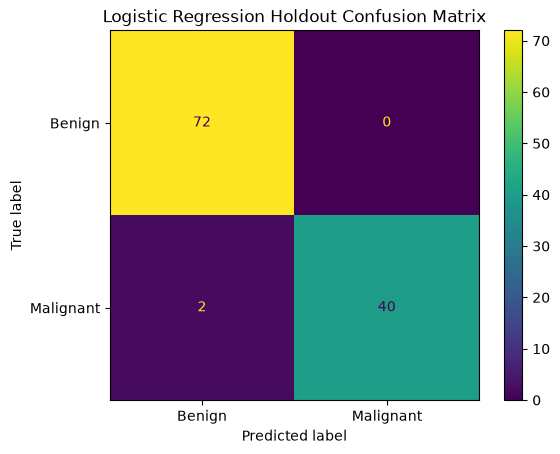

In [26]:
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

display.plot()
plt.title("Logistic Regression Holdout Confusion Matrix")
plt.show()

In [27]:
tn, fp, fn, tp = cm.ravel()

print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

True negatives: 72
False positives: 0
False negatives: 2
True positives: 40


In [28]:
from sklearn.metrics import roc_curve

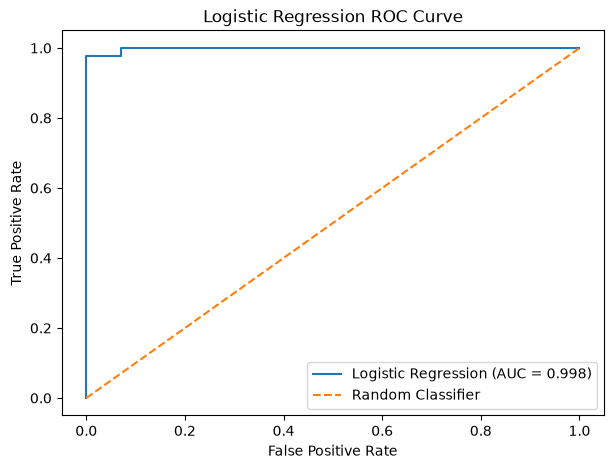

In [29]:
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Logistic Regression (AUC = {test_roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

In [30]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
feature_names = development_df.drop(
    columns=["id", "diagnosis"]
).columns.tolist()

In [32]:
X_development_scaled_df = pd.DataFrame(
    X_development_scaled,
    columns=feature_names
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_names
)

In [33]:
import shap

shap_explainer = shap.LinearExplainer(
    (final_theta, final_bias),
    X_development_scaled_df
)

shap_values = shap_explainer(
    X_test_scaled_df
)

Background dataset has 455 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=455 when initializing the masker.


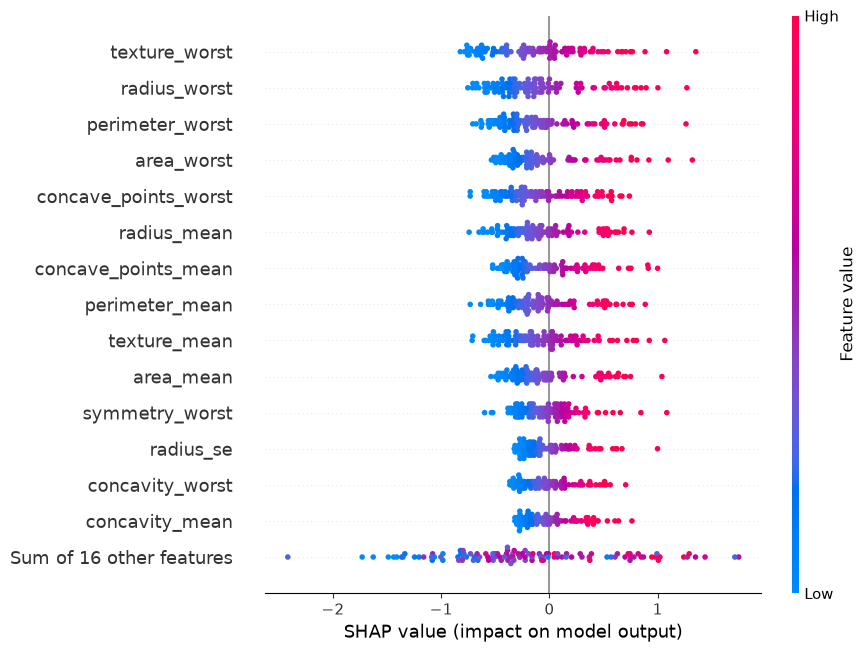

In [34]:
shap_values.data = X_test

shap.plots.beeswarm(
    shap_values,
    max_display=15
)